# Baseline DenseNet

## Objective
Establish a lower-bound baseline for DenseNet-121 trained from scratch with a direct
linear head, no class weighting, and no regularisation. All subsequent experiments
build on this reference point.
 
## Architecture
 
| Component | 01. Baseline |
|---|---|
| Pretrained | False |
| Frozen backbone | False |
| Hidden dim | 0 (direct linear head) |
| Dropout | 0.0 |
| Pos weight | None |
| Optimiser | AdamW |
| Weight decay | 1e-4 |
| LR | 1e-3 |
| Epochs | 30 |
 
## Hypothesis
Training from random initialisation with no class-balancing establishes the performance
floor. The majority class (nevus) will dominate and melanoma recall will be poor, but
this gives a clean reference point for all subsequent iterations.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path
 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
 
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))
 
from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.densenet import get_densenet121
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
 
import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
model = get_densenet121(
    num_classes=1,
    pretrained=False,
    freeze_backbone=False,
    dropout=0.0,
    hidden_dim=0,
).to(device)
 
criterion = nn.BCEWithLogitsLoss()
 
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
 
num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)
 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print('Pretrained: False | Frozen: False | Dropout: 0.0 | Hidden dim: 0 | Pos weight: None')

Trainable params: 6,954,881 / 6,954,881
Pretrained: False | Frozen: False | Dropout: 0.0 | Hidden dim: 0 | Pos weight: None


In [4]:
from pathlib import Path

path = Path("C:/Users/1008462/Desktop/50.039-Deep-Learning/data_new/images/train/ISIC_0026252.jpg")
print(path.exists())

True


In [5]:
import os

root = "C:/Users/1008462/Desktop/50.039-Deep-Learning"

for dirpath, _, filenames in os.walk(root):
    if "ISIC_0026252.jpg" in filenames:
        print("Found at:", os.path.join(dirpath, "ISIC_0026252.jpg"))

Found at: C:/Users/1008462/Desktop/50.039-Deep-Learning\data_new\images\train\ISIC_0026252.jpg
Found at: C:/Users/1008462/Desktop/50.039-Deep-Learning\data_new\raw\dataverse_files\HAM10000_images_combined_600x450\ISIC_0026252.jpg


## Training Loop

In [6]:
best_val_auc = 0.0
train_history, val_history = [], []
 
for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics   = validate_one_epoch(model, val_loader, criterion, device)
 
    scheduler.step()
 
    train_history.append(train_metrics)
    val_history.append(val_metrics)
 
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")
 
    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/densenet121_baseline_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/30]
  Train | Loss: 0.3307, Bal Acc: 0.5028, Recall: 0.0114, F2: 0.0140, AUC: 0.6768
  Val   | Loss: 0.3374, Bal Acc: 0.5000, Recall: 0.0000, F2: 0.0000, AUC: 0.7820
  -> Saved best model (val AUC: 0.7820)


Epoch [2/30]
  Train | Loss: 0.3146, Bal Acc: 0.5022, Recall: 0.0057, F2: 0.0071, AUC: 0.7212
  Val   | Loss: 0.2983, Bal Acc: 0.5013, Recall: 0.0042, F2: 0.0053, AUC: 0.8066
  -> Saved best model (val AUC: 0.8066)


Epoch [3/30]
  Train | Loss: 0.3063, Bal Acc: 0.5023, Recall: 0.0057, F2: 0.0071, AUC: 0.7529
  Val   | Loss: 0.2972, Bal Acc: 0.5000, Recall: 0.0000, F2: 0.0000, AUC: 0.8221
  -> Saved best model (val AUC: 0.8221)


Epoch [4/30]
  Train | Loss: 0.2933, Bal Acc: 0.5081, Recall: 0.0194, F2: 0.0240, AUC: 0.7829
  Val   | Loss: 0.2814, Bal Acc: 0.5338, Recall: 0.0805, F2: 0.0963, AUC: 0.8304
  -> Saved best model (val AUC: 0.8304)


Epoch [5/30]
  Train | Loss: 0.2864, Bal Acc: 0.5159, Recall: 0.0376, F2: 0.0461, AUC: 0.8004
  Val   | Loss: 0.2814, Bal Acc: 0.5571, Recall: 0.1398, F2: 0.1613, AUC: 0.8371
  -> Saved best model (val AUC: 0.8371)


...

Epoch [26/30]
  Train | Loss: 0.2510, Bal Acc: 0.5685, Recall: 0.1471, F2: 0.1739, AUC: 0.8622
  Val   | Loss: 0.2646, Bal Acc: 0.6037, Recall: 0.2331, F2: 0.2632, AUC: 0.8592


Epoch [27/30]
  Train | Loss: 0.2474, Bal Acc: 0.5779, Recall: 0.1665, F2: 0.1957, AUC: 0.8672
  Val   | Loss: 0.2615, Bal Acc: 0.6157, Recall: 0.2627, F2: 0.2919, AUC: 0.8621


Epoch [28/30]
  Train | Loss: 0.2503, Bal Acc: 0.5663, Recall: 0.1448, F2: 0.1706, AUC: 0.8635
  Val   | Loss: 0.2636, Bal Acc: 0.5885, Recall: 0.1949, F2: 0.2250, AUC: 0.8580


Epoch [29/30]
  Train | Loss: 0.2464, Bal Acc: 0.5808, Recall: 0.1745, F2: 0.2039, AUC: 0.8679
  Val   | Loss: 0.2669, Bal Acc: 0.6083, Recall: 0.2458, F2: 0.2751, AUC: 0.8568


Epoch [30/30]
  Train | Loss: 0.2512, Bal Acc: 0.5737, Recall: 0.1619, F2: 0.1892, AUC: 0.8624
  Val   | Loss: 0.2665, Bal Acc: 0.6280, Recall: 0.2924, F2: 0.3200, AUC: 0.8586


## Plot Train and Validation Curves

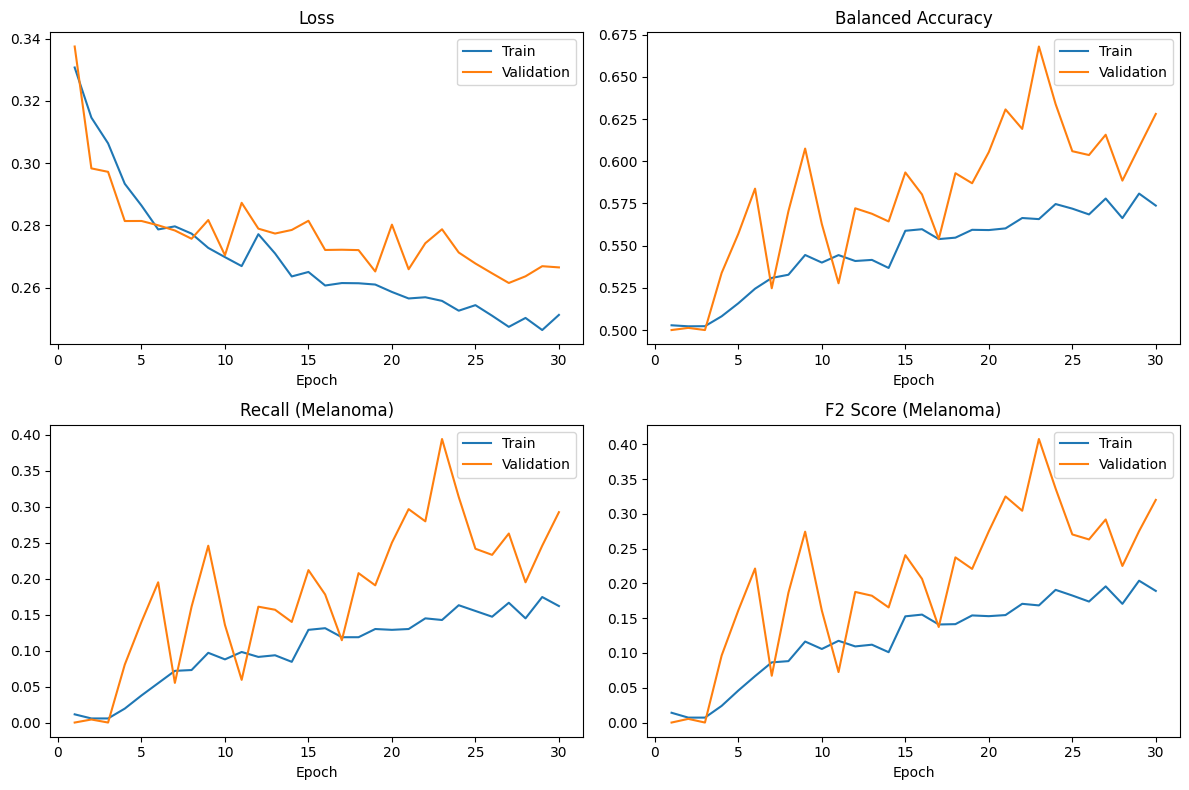

In [7]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [8]:
model.load_state_dict(torch.load(str(ROOT / 'models/densenet121_baseline_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

C:\Users\1008462\AppData\Local\Temp\ipykernel_15080\2815150809.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(str(ROOT / 'models/densen

Best threshold: 0.17 | Val F2: 0.6036


## Test Set Evaluation

Threshold:          0.17
AUC-ROC:            0.8570
Balanced Accuracy:  0.7640
F2 Score:           0.5771

              precision    recall  f1-score   support

Non-Melanoma     0.9663    0.7269    0.8296      1340
    Melanoma     0.2724    0.8012    0.4065       171

    accuracy                         0.7353      1511
   macro avg     0.6193    0.7640    0.6181      1511
weighted avg     0.8877    0.7353    0.7818      1511



C:\Users\1008462\Desktop\50.021_project_group4\venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


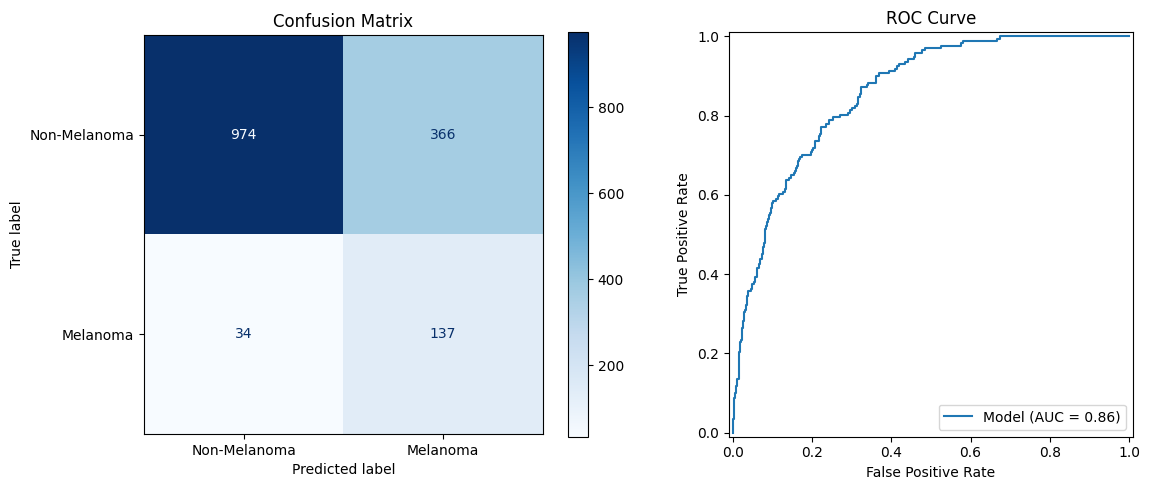

In [9]:
evaluate_model(model, test_loader, device, threshold=best_threshold)